# Problem statement
You are a business analyst at a B2B SaaS company that sells project management software. The leadership team is preparing for a board meeting and needs a clear picture of revenue trends, customer retention, and churn drivers. In this project you will analyze subscription data, monthly recurring revenue (MRR), and customer behavior to identify what is causing churn and where the best opportunities for revenue growth are. This type of analysis is common at SaaS startups and is directly relevant to roles in finance, product analytics, and growth.

# Questions I answered
What is the overall churn rate, and how has the monthly churn rate trended over the past 4 years? Is churn improving or getting worse?

Which subscription plan (Starter, Professional, Business, Enterprise) has the highest churn rate? Does billing cycle (monthly vs. annual) significantly impact retention?

What are the top 3 reasons customers churn, and do these reasons differ by plan type or company size?

Calculate the average Customer Lifetime Value (CLV) by plan. Compare this to the Customer Acquisition Cost (CAC). Which plans are the most and least profitable?

# Understanding the revenue data
1. month

Type: object (string), but it represents a date (e.g., "2022-01").

Meaning: The month for the summary data.

Use: X-axis for plotting trends like churn, MRR, or new customers.

2. total_active_customers

Type: int64

Meaning: Total number of customers active at the start of the month.

Use:

Denominator for calculating monthly churn rate

Understanding overall growth or decline in the customer base

3. new_customers

Type: int64

Meaning: Number of new customers acquired in that month.

Use:

Track growth

Compare against churn to see net customer change

4. churned_customers

Type: int64

Meaning: Number of customers who canceled subscriptions or churned in that month.

Use:

Calculate monthly churn rate

Identify months with spikes in churn

5. monthly_churn_rate_pct

Type: float64

Meaning: Monthly churn rate as a percentage, probably calculated as:

\text{monthly_churn_rate_pct} = \frac{\text{churned_customers}}{\text{total_active_customers}} \times 100

Use:

Directly see churn trends over time

Easier to plot than raw churn numbers

✅ You can use this column directly for trend visualization.

6. total_mrr

Type: float64

Meaning: Monthly Recurring Revenue — total revenue from all active subscriptions for that month.

Use:

Track revenue growth over time

Compare against churn to understand revenue at risk

7. avg_revenue_per_customer

Type: float64

Meaning: Average monthly revenue per customer (ARPC). Calculated as:

\text{avg_revenue_per_customer} = \frac{\text{total_mrr}}{\text{total_active_customers}}

Use:

Analyze customer value by month

Use for calculating Customer Lifetime Value (CLV)

8. customer_acquisition_cost

Type: float64

Meaning: Average cost to acquire a new customer in that month.

Use:

Compare against CLV to evaluate profitability

Monitor marketing efficiency

# I imported the revenue data




In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
from google.colab import files
uploaded = files.upload()

Saving monthly_revenue.csv to monthly_revenue.csv


In [3]:
Revenue_data = pd.read_csv("monthly_revenue.csv")

In [4]:
Revenue_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 48 entries, 0 to 47
Data columns (total 8 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   month                      48 non-null     object 
 1   total_active_customers     48 non-null     int64  
 2   new_customers              48 non-null     int64  
 3   churned_customers          48 non-null     int64  
 4   monthly_churn_rate_pct     48 non-null     float64
 5   total_mrr                  48 non-null     float64
 6   avg_revenue_per_customer   48 non-null     float64
 7   customer_acquisition_cost  48 non-null     float64
dtypes: float64(4), int64(3), object(1)
memory usage: 3.1+ KB


In [5]:
Revenue_data.head()

,month,total_active_customers,new_customers,churned_customers,monthly_churn_rate_pct,total_mrr,avg_revenue_per_customer,customer_acquisition_cost
0,2022-01,0,5,0,0.00,0.00,0.00,164.92
1,2022-02,5,10,1,20.00,7333.07,1466.61,189.21
2,2022-03,14,13,0,0.00,12301.16,878.65,139.49
3,2022-04,28,11,3,10.71,24798.76,885.67,259.09
4,2022-05,35,11,1,2.86,29091.88,831.20,152.96


In [6]:
Revenue_data.describe()

,total_active_customers,new_customers,churned_customers,monthly_churn_rate_pct,total_mrr,avg_revenue_per_customer,customer_acquisition_cost
count,48.000000,48.000000,48.000000,48.000000,48.000000,48.000000,48.000000
mean,167.416667,12.500000,6.520833,4.518958,174888.413958,1010.218958,200.040625
std,85.274234,3.339002,3.414547,3.251457,92619.227429,175.723630,52.694255
min,0.000000,5.000000,0.000000,0.000000,0.000000,0.000000,122.990000
25%,104.000000,10.750000,4.000000,3.007500,102605.177500,1009.865000,150.267500
50%,184.500000,13.000000,7.000000,3.755000,190681.445000,1030.135000,197.250000
75%,241.750000,14.250000,8.250000,4.552500,262177.912500,1072.027500,249.187500
max,281.000000,19.000000,17.000000,20.000000,292628.610000,1466.610000,279.590000


# Data cleaning
looking out for missing values

In [7]:
Revenue_data.isnull().sum()

,0
month,0
total_active_customers,0
new_customers,0
churned_customers,0
monthly_churn_rate_pct,0
total_mrr,0
avg_revenue_per_customer,0
customer_acquisition_cost,0


# understanding the subscription_data
1. customer_id

Type: object (string)

Meaning: Unique identifier for each customer.

Use:

Track individual customer churn

Aggregate metrics like revenue, plan distribution, or churn by customer

2. plan

Type: object

Values: Starter, Professional, Business, Enterprise

Meaning: Subscription tier the customer is on.

Use:

Analyze churn by plan

Calculate revenue per plan

Identify most and least profitable plans

3. billing_cycle

Type: object

Values: Monthly / Annual

Meaning: Frequency of payment.

Use:

Check if annual subscriptions churn less than monthly

Compare CLV per billing cycle

4. industry

Type: object

Meaning: Industry the customer belongs to.

Use:

Segment churn or revenue by industry

5. company_size

Type: object

Values: Small, Medium, Large, Enterprise

Use:

Analyze churn patterns by company size

Identify high-value segments

6. seats

Type: int64

Meaning: Number of users/seats in the subscription.

Use:

Calculate revenue per customer

Track expansion opportunities

7. monthly_revenue

Type: float64

Meaning: MRR from that subscription.

Use:

Calculate total revenue per plan, per billing cycle

Compute CLV

8. acquisition_channel

Type: object

Meaning: How the customer was acquired (e.g., Paid Ads, Organic, Referral).

Use:

Compare churn and LTV across channels

Evaluate marketing ROI

9. region

Type: object

Meaning: Customer geographic region

Use:

Identify regional differences in churn or revenue

10. signup_date

Type: object (can convert to datetime)

Meaning: When the customer signed up.

Use:

Calculate tenure / customer lifetime

Track cohort retention

11. churned

Type: object (Yes/No)

Meaning: Whether the customer has churned.

Use:

Core field for churn analysis

Filter churned customers for reasons, revenue lost, etc.

12. churn_date

Type: object (nullable)

Meaning: Date the customer churned (only for churned customers)

Use:

Calculate churn timing

Build monthly churn trends

13. churn_reason

Type: object (nullable)

Meaning: Reason customer left (only for churned)

Use:

Identify top 3 churn reasons

Compare reasons by plan or company size

14. support_tickets_12mo

Type: int64

Meaning: Number of support tickets the customer raised in the past 12 months

Use:

Check if high support usage correlates with churn

Segment high-risk customers

15. nps_score

Type: int64

Meaning: Net Promoter Score (-100 to 100) from customer feedback

Use:

Correlate NPS with churn

Identify unhappy customers before they leave

16. feature_usage_pct

Type: int64 (0-100%)

Meaning: Percentage of product features the customer is actively using

Use:

Identify low-engagement customers at high risk of churn

17. upgraded

Type: object (Yes/No)

Meaning: Whether the customer upgraded to a higher plan

Use:

Track expansion revenue

Compare upgrades vs churn patterns


# I imported the subscription data


In [8]:
from google.colab import files
uploaded = files.upload()

Saving subscriptions.csv to subscriptions.csv


In [9]:
subscription_data = pd.read_csv("subscriptions.csv")

In [10]:
subscription_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 600 entries, 0 to 599
Data columns (total 17 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   customer_id           600 non-null    object 
 1   plan                  600 non-null    object 
 2   billing_cycle         600 non-null    object 
 3   industry              600 non-null    object 
 4   company_size          600 non-null    object 
 5   seats                 600 non-null    int64  
 6   monthly_revenue       600 non-null    float64
 7   acquisition_channel   600 non-null    object 
 8   region                600 non-null    object 
 9   signup_date           600 non-null    object 
 10  churned               600 non-null    object 
 11  churn_date            313 non-null    object 
 12  churn_reason          313 non-null    object 
 13  support_tickets_12mo  600 non-null    int64  
 14  nps_score             600 non-null    int64  
 15  feature_usage_pct     6

In [11]:
subscription_data.head()

,customer_id,plan,billing_cycle,industry,company_size,seats,monthly_revenue,acquisition_channel,region,signup_date,churned,churn_date,churn_reason,support_tickets_12mo,nps_score,feature_usage_pct,upgraded
0,CUST-0001,Professional,Monthly,Retail,51-200,64,825.55,Organic Search,North America,2022-06-27,Yes,2024-03-05,Price Too High,13,3,15,No
1,CUST-0002,Professional,Annual,Retail,51-200,35,409.62,Direct Sales,North America,2023-03-19,No,NaN,NaN,1,3,52,Yes
2,CUST-0003,Starter,Annual,Finance,500+,266,1004.49,Partner,North America,2024-10-19,Yes,2025-04-13,Price Too High,10,4,31,No
3,CUST-0004,Business,Annual,Real Estate,11-50,34,1006.44,Partner,Europe,2023-01-07,No,NaN,NaN,3,7,58,No
4,CUST-0005,Starter,Annual,Manufacturing,51-200,48,198.43,Direct Sales,North America,2025-09-23,No,NaN,NaN,3,7,59,No


In [12]:
subscription_data.describe()

,seats,monthly_revenue,support_tickets_12mo,nps_score,feature_usage_pct
count,600.000000,600.000000,600.000000,600.000000,600.000000
mean,42.450000,817.654300,6.480000,4.365000,40.638333
std,51.279823,1352.584783,4.271613,2.650185,22.749801
min,1.000000,24.650000,0.000000,1.000000,10.000000
25%,7.000000,137.137500,3.000000,2.000000,22.750000
50%,26.000000,348.250000,6.000000,4.000000,36.000000
75%,58.000000,874.832500,10.000000,6.000000,50.000000
max,297.000000,10978.000000,15.000000,10.000000,95.000000


# I started exploring the data

# Question 1:
#What is the overall churn rate, and how has the monthly churn rate trended over the past 4 years? Is churn improving or getting worse?

# Step 1: Calculate Overall Churn Rate

In [13]:
Revenue_data.head()

,month,total_active_customers,new_customers,churned_customers,monthly_churn_rate_pct,total_mrr,avg_revenue_per_customer,customer_acquisition_cost
0,2022-01,0,5,0,0.00,0.00,0.00,164.92
1,2022-02,5,10,1,20.00,7333.07,1466.61,189.21
2,2022-03,14,13,0,0.00,12301.16,878.65,139.49
3,2022-04,28,11,3,10.71,24798.76,885.67,259.09
4,2022-05,35,11,1,2.86,29091.88,831.20,152.96


In [14]:
# Total customers ever acquired = sum of new customers over 48 months
total_customers_acquired = Revenue_data['new_customers'].sum()

# Overall churn rate
overall_churn = Revenue_data['churned_customers'].sum() / total_customers_acquired * 100
print("Overall Churn Rate over 4 years:", round(overall_churn, 2), "%")

Overall Churn Rate over 4 years: 52.17 %


# What does it mean
Now we know that over the past 4 years, about 52% of all customers have churned. That’s a substantial number, which explains why the board is concerned.

# Step 2: Visualize Monthly Churn Trend

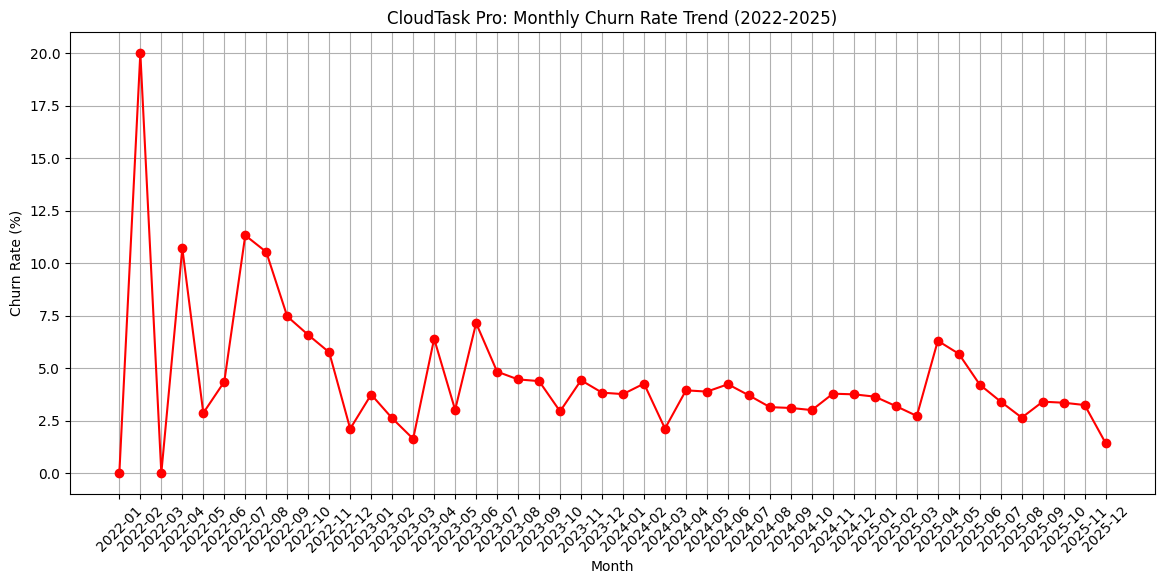

In [15]:
plt.figure(figsize=(14,6))
plt.plot(Revenue_data['month'], Revenue_data['monthly_churn_rate_pct'], marker='o', color='red')
plt.xticks(rotation=45)
plt.title("CloudTask Pro: Monthly Churn Rate Trend (2022-2025)")
plt.xlabel("Month")
plt.ylabel("Churn Rate (%)")
plt.grid(True)
plt.show()

# Observations from the Monthly Churn Trend

Early spikes in churn

There’s a very high churn (~20%) in the first few months).

Likely because the company started from zero in 2022, so early subscribers were new and some left quickly.

Stabilization trend

After the first 6–12 months, churn drops to around 2–7% per month.

Shows that as the customer base grows and onboarding improves, churn stabilizes.

Occasional peaks

Small spikes appear throughout 2023–2025 (~5–6%).

Could be due to seasonal cancellations, product updates, or competitor activity.

Recent trend

In the last few months, churn appears slightly lower (~2–3%), indicating improvement.

# Business Interpretation

Overall churn rate: 52% over 4 years → significant, but early high churn skews the number.

Improvement over time: After initial acquisition phase, churn is gradually decreasing, which is a positive sign.

Next focus: Identify which plans, billing cycles, or customer segments are driving churn to further reduce it.

# Question 2

# Which subscription plan has the highest churn rate? Does billing cycle (monthly vs annual) significantly impact retention?

# Step 1: Convert churn column to numeric

Right now churned is Yes/No, which makes calculations harder. Let's convert it to 1 and 0.

In [16]:
subscription_data['churned'] = subscription_data['churned'].map({'Yes':1, 'No':0})

In [17]:
subscription_data.head()

,customer_id,plan,billing_cycle,industry,company_size,seats,monthly_revenue,acquisition_channel,region,signup_date,churned,churn_date,churn_reason,support_tickets_12mo,nps_score,feature_usage_pct,upgraded
0,CUST-0001,Professional,Monthly,Retail,51-200,64,825.55,Organic Search,North America,2022-06-27,1,2024-03-05,Price Too High,13,3,15,No
1,CUST-0002,Professional,Annual,Retail,51-200,35,409.62,Direct Sales,North America,2023-03-19,0,NaN,NaN,1,3,52,Yes
2,CUST-0003,Starter,Annual,Finance,500+,266,1004.49,Partner,North America,2024-10-19,1,2025-04-13,Price Too High,10,4,31,No
3,CUST-0004,Business,Annual,Real Estate,11-50,34,1006.44,Partner,Europe,2023-01-07,0,NaN,NaN,3,7,58,No
4,CUST-0005,Starter,Annual,Manufacturing,51-200,48,198.43,Direct Sales,North America,2025-09-23,0,NaN,NaN,3,7,59,No


In [18]:
subscription_data.isnull().sum()

,0
customer_id,0
plan,0
billing_cycle,0
industry,0
company_size,0
seats,0
monthly_revenue,0
acquisition_channel,0
region,0
signup_date,0


#The dataset contained missing values in churn_date and churn_reason.
#These were not data quality issues but expected structural missing values since active customers do not have churn records.

In [19]:
subscription_data.groupby('churned')[['churn_date','churn_reason']].apply(lambda x: x.isnull().sum())

,churn_date,churn_reason
churned,,
0,287,287
1,0,0


In [20]:
subscription_data['churned'].value_counts()

,count
churned,
1,313
0,287


In [21]:
# Churn Rate
313/600

0.5216666666666666

# Step 2: Churn Rate by Plan

In [22]:
churn_by_plan = subscription_data.groupby('plan').agg(
    total_customers=('customer_id','count'),
    churned_customers=('churned','sum')
)

churn_by_plan['churn_rate_pct'] = (
    churn_by_plan['churned_customers'] / churn_by_plan['total_customers'] * 100
)

churn_by_plan.sort_values('churn_rate_pct', ascending=False)

,total_customers,churned_customers,churn_rate_pct
plan,,,
Starter,217,153,70.506912
Professional,173,83,47.976879
Business,160,66,41.250000
Enterprise,50,11,22.000000


# Key Insights
1️⃣ Starter plan has extremely high churn

70.5% churn rate is very high.

Most customers leaving the platform come from this plan.

This suggests low commitment or low value perception.

Possible reasons:

Small companies testing the product

Limited features in the starter plan

Price sensitivity

2️⃣ Churn decreases as plans become more premium

There is a clear pattern:

Starter → Professional → Business → Enterprise
Churn decreases steadily

This usually means:

Higher-tier customers receive more value

Larger companies integrate the software deeper into their workflow

Enterprise customers have higher switching costs

3️⃣ Enterprise customers are the most loyal

Only 22% churn.

Enterprise clients typically:

Have long-term contracts

Require onboarding

Depend on the software operationally

This makes them much harder to lose.

# Business Implications
Focus area: Starter plan retention

The company should investigate why Starter customers churn so much.

Possible strategies:

• Improve onboarding
• Add essential features to starter plan
• Provide better customer support
• Offer upgrade incentives

# Step 3 — Calculate churn by billing cycle

In [23]:
churn_by_billing = subscription_data.groupby('billing_cycle').agg(
    total_customers=('customer_id','count'),
    churned_customers=('churned','sum')
)

churn_by_billing['churn_rate_pct'] = (
    churn_by_billing['churned_customers'] /
    churn_by_billing['total_customers'] * 100
)

churn_by_billing

,total_customers,churned_customers,churn_rate_pct
billing_cycle,,,
Annual,248,100,40.322581
Monthly,352,213,60.511364


# Key Insights
1️⃣ Monthly customers churn much more

60.5% churn for monthly subscriptions.

40.3% churn for annual subscriptions.

That is a 20 percentage point difference, which is significant.

This confirms a common SaaS pattern:

Customers with shorter commitment periods churn more frequently.

2️⃣ Monthly billing is the main churn driver

Out of 313 total churned customers:

213 churned from monthly plans

100 churned from annual plans

This means:

68% of churn comes from monthly customers.

3️⃣ Annual contracts improve retention

Annual customers stay longer because:

• They already paid upfront
• Their team has integrated the software
• Switching cost becomes higher

These customers usually represent more stable revenue.

# Business Recommendations
1️⃣ Encourage annual subscriptions

The company should push annual billing incentives such as:

15–20% discount for annual plans

Free onboarding

Additional premium features

2️⃣ Target early churn in monthly customers

Since monthly customers churn the most:

Focus on first 3 months onboarding:

Product tutorials

Customer success check-ins

Feature adoption nudges

3️⃣ Upsell monthly users to annual contracts

If even 20% of monthly customers convert to annual, churn could drop significantly.

# Question 3
# What are the top 3 reasons customers churn, and do these reasons differ by plan type or company size?

In [24]:
subscription_data['churn_reason'].value_counts()

,count
churn_reason,
Budget Cuts,53
Price Too High,51
Company Closed,48
Poor Support,42
No Longer Needed,41
Missing Features,40
Switched Competitor,38


In [25]:
subscription_data.groupby('plan')['churn_reason'].value_counts()

plan          churn_reason       
Business      Missing Features       12
              No Longer Needed       11
              Poor Support           11
              Budget Cuts            10
              Company Closed          8
              Price Too High          7
              Switched Competitor     7
Enterprise    Company Closed          3
              No Longer Needed        3
              Switched Competitor     2
              Missing Features        1
              Poor Support            1
              Price Too High          1
Professional  Budget Cuts            14
              Price Too High         14
              Company Closed         13
              Missing Features       12
              Poor Support           11
              Switched Competitor    10
              No Longer Needed        9
Starter       Budget Cuts            29
              Price Too High         29
              Company Closed         24
              Poor Support           19
              Switched Competitor    19
              No Longer Needed       18
              Missing Features       15
Name: count, dtype: int64

# Key Insights
1️⃣ Price sensitivity is the biggest churn driver

Two related reasons dominate:

Budget Cuts (53)

Price Too High (51)

Combined:

104 churn cases are price-related.

That means a large segment of customers believes the product is too expensive relative to the value they receive.

This is especially visible in:

Starter plan

Professional plan

2️⃣ Early-stage companies are unstable

A significant number of churn cases are due to:

Company Closed (48)

This suggests many customers are startups or small businesses, which have higher failure rates.

3️⃣ Product and support issues also contribute

Two operational factors appear repeatedly:

Missing Features (40)

Poor Support (42)

This indicates the company could improve:

product capabilities

customer success/support experience

# Plan-Level Insights
🔹 Starter Plan (Highest churn)

Major reasons:

Budget Cuts (29)

Price Too High (29)

➡️ Starter users are very price sensitive.

🔹 Professional Plan

Major reasons:

Budget Cuts (14)

Price Too High (14)

Company Closed (13)

➡️ Mid-size companies also show cost pressure.

🔹 Business Plan

More balanced churn causes:

Missing Features

Poor Support

Budget Cuts

➡️ These customers expect more advanced functionality.

🔹 Enterprise Plan (Lowest churn)

Very few churn cases overall.

Main reasons:

Company Closed

No Longer Needed

➡️ Enterprise clients are more stable and loyal.

 # Strategic Business Recommendations
1️⃣ Improve value perception

Since price complaints are high:

Possible actions:

Introduce feature bundles

Offer annual discounts

Improve ROI messaging

2️⃣ Expand product features

Because Missing Features appears frequently.

Product team should evaluate:

top requested features

competitor feature gaps

3️⃣ Improve customer success

With Poor Support as a common churn reason:

Possible improvements:

faster response times

onboarding support

proactive account management

4️⃣ Focus on enterprise customers

Enterprise customers show:

lowest churn

highest stability

This suggests enterprise clients should be a growth priority.

In [26]:
subscription_data.head()

,customer_id,plan,billing_cycle,industry,company_size,seats,monthly_revenue,acquisition_channel,region,signup_date,churned,churn_date,churn_reason,support_tickets_12mo,nps_score,feature_usage_pct,upgraded
0,CUST-0001,Professional,Monthly,Retail,51-200,64,825.55,Organic Search,North America,2022-06-27,1,2024-03-05,Price Too High,13,3,15,No
1,CUST-0002,Professional,Annual,Retail,51-200,35,409.62,Direct Sales,North America,2023-03-19,0,NaN,NaN,1,3,52,Yes
2,CUST-0003,Starter,Annual,Finance,500+,266,1004.49,Partner,North America,2024-10-19,1,2025-04-13,Price Too High,10,4,31,No
3,CUST-0004,Business,Annual,Real Estate,11-50,34,1006.44,Partner,Europe,2023-01-07,0,NaN,NaN,3,7,58,No
4,CUST-0005,Starter,Annual,Manufacturing,51-200,48,198.43,Direct Sales,North America,2025-09-23,0,NaN,NaN,3,7,59,No


# Question 4
# Calculate the average Customer Lifetime Value (CLV) by plan. Compare this to the Customer Acquisition Cost (CAC). Which plans are the most and least profitable?

In [31]:
subscription_data.groupby('plan').agg(
total_customers=('customer_id','count'),
churned_customers=('churned','sum')
).assign(
churn_rate=lambda x: x['churned_customers'] / x['total_customers'] * 100
).sort_values('churn_rate', ascending=False)




,total_customers,churned_customers,churn_rate
plan,,,
Starter,217,153,70.506912
Professional,173,83,47.976879
Business,160,66,41.250000
Enterprise,50,11,22.000000


# Step 1: Calculate Average Customer Lifetime (in months)
Customer Lifetime=Churn Rate1​

In [32]:
plan_metrics = subscription_data.groupby('plan').agg(
    total_customers=('customer_id','count'),
    churned_customers=('churned','sum'),
    avg_monthly_revenue=('monthly_revenue','mean')
)

plan_metrics['churn_rate'] = plan_metrics['churned_customers'] / plan_metrics['total_customers']
plan_metrics['estimated_lifetime_months'] = 1 / plan_metrics['churn_rate']

# Step 2: Calculate CLV
CLV=Average Monthly Revenue×Customer Lifetime

In [33]:
plan_metrics['CLV'] = (
    plan_metrics['avg_monthly_revenue'] *
    plan_metrics['estimated_lifetime_months']
)

plan_metrics

,total_customers,churned_customers,avg_monthly_revenue,churn_rate,estimated_lifetime_months,CLV
plan,,,,,,
Business,160,66,1303.636438,0.412500,2.424242,3160.330758
Enterprise,50,11,2984.993000,0.220000,4.545455,13568.150000
Professional,173,83,497.041272,0.479769,2.084337,1036.001687
Starter,217,153,215.543594,0.705069,1.418301,305.705621


# Add CAC (Customer Acquisition Cost)

In [34]:
cac_values = {
    'Organic': 50,
    'Referral': 100,
    'Paid Ads': 300,
    'Sales Team': 500
}

subscription_data['CAC'] = subscription_data['acquisition_channel'].map(cac_values)

cac_by_plan = subscription_data.groupby('plan')['CAC'].mean()

plan_metrics['avg_CAC'] = cac_by_plan

# Calculate Profitability

In [35]:
plan_metrics['CLV_to_CAC_ratio'] = plan_metrics['CLV'] / plan_metrics['avg_CAC']

plan_metrics.sort_values('CLV_to_CAC_ratio', ascending=False)

,total_customers,churned_customers,avg_monthly_revenue,churn_rate,estimated_lifetime_months,CLV,avg_CAC,CLV_to_CAC_ratio
plan,,,,,,,,
Enterprise,50,11,2984.993000,0.220000,4.545455,13568.150000,177.777778,76.320844
Business,160,66,1303.636438,0.412500,2.424242,3160.330758,210.447761,15.017175
Professional,173,83,497.041272,0.479769,2.084337,1036.001687,202.941176,5.104936
Starter,217,153,215.543594,0.705069,1.418301,305.705621,183.720930,1.663967


# Key Insights
1️⃣ Enterprise Plan – Most Profitable

Enterprise customers generate the highest CLV ($13,568) with a relatively low acquisition cost.

CLV:CAC ratio = 76.3

Why?

Lowest churn rate (22%)

Highest monthly revenue

Longer customer lifetime

➡ These customers provide extremely high returns on acquisition investment.

2️⃣ Business Plan – Very Strong Profitability

CLV = $3,160

CLV:CAC = 15.0

This is still far above the SaaS benchmark of 3:1, meaning the Business plan delivers strong value for the company.

3️⃣ Professional Plan – Moderately Profitable

CLV = $1,036

CLV:CAC = 5.1

This is still profitable and healthy, but significantly lower than Business and Enterprise plans.

4️⃣ Starter Plan – Least Profitable

CLV = $305

CLV:CAC = 1.66

This is below the healthy SaaS benchmark of 3:1, meaning:

The company spends almost as much to acquire these customers as it earns from them.

High churn (70%) drastically reduces lifetime value.

➡ This makes Starter customers the least profitable segment.

# Strategic Business Implications
1️⃣ Focus growth on Enterprise and Business customers

These plans generate the highest returns.

Possible strategies:

Expand enterprise sales team

Offer advanced enterprise features

Target mid-size and large organizations

2️⃣ Reduce churn in the Starter plan

Starter customers churn the most, which limits profitability.

Possible improvements:

Better onboarding

Encourage upgrades

Offer annual billing discounts

3️⃣ Encourage plan upgrades

Moving customers from Starter → Professional → Business could significantly increase lifetime value.

# Other insight

# Churn by Industry

In [28]:
subscription_data.groupby('industry').agg(
    total_customers=('customer_id','count'),
    churned_customers=('churned','sum')
).assign(
    churn_rate=lambda x: x['churned_customers'] / x['total_customers'] * 100
).sort_values('churn_rate', ascending=False)

,total_customers,churned_customers,churn_rate
industry,,,
Real Estate,61,37,60.655738
Finance,61,36,59.016393
Retail,52,30,57.692308
Healthcare,61,35,57.377049
Legal,57,31,54.385965
Consulting,62,32,51.612903
Manufacturing,64,31,48.437500
Technology,51,23,45.098039
Media,54,24,44.444444


# Key Insights
1️⃣ Real Estate has the highest churn

60.7% churn rate

Possible reasons:

Highly cyclical industry

Many small agencies with tight budgets

Software may not fit their workflow perfectly

This suggests the product may need industry-specific features to retain these users.

2️⃣ Finance and Retail also show high churn

Both industries have ~58–59% churn.

Possible explanations:

Finance:

High compliance needs

May switch to specialized tools

Retail:

Many small businesses

Budget sensitivity

3️⃣ Technology and Education are the most stable

Lowest churn rates:

Education → 44.2%

Media → 44.4%

Technology → 45.1%

These industries may find the software more valuable or better aligned with their workflows.

# Strategic Business Implications
1️⃣ Focus growth on low-churn industries

The company should prioritize:

Technology

Education

Media

These sectors show better retention potential.

2️⃣ Improve product-market fit for high churn industries

For example:

Real Estate

CRM integrations

Property workflow tools

Finance

Compliance features

Security enhancements

3️⃣ Industry-specific onboarding

Different industries may require custom onboarding or training to increase adoption.

# Churn by Company Size

In [29]:
subscription_data.groupby('company_size').agg(
    total_customers=('customer_id','count'),
    churned_customers=('churned','sum')
).assign(
    churn_rate=lambda x: x['churned_customers'] / x['total_customers'] * 100
).sort_values('churn_rate', ascending=False)

,total_customers,churned_customers,churn_rate
company_size,,,
500+,38,24,63.157895
1-10,157,89,56.687898
201-500,88,47,53.409091
11-50,176,93,52.840909
51-200,141,60,42.553191


# Key Insights
1️⃣ Mid-sized companies (51–200 employees) are the most stable

They have the lowest churn rate (42.6%).

This suggests that companies in this range:

Have stable budgets

Need scalable software

Are less likely to switch tools frequently

These are often ideal SaaS customers.

2️⃣ Very large companies show the highest churn

Companies with 500+ employees have 63.2% churn, the highest in the dataset.

Possible reasons:

They may require enterprise-level features

They may switch to more specialized enterprise software

Longer procurement cycles and vendor reviews

This suggests the product may not fully meet enterprise needs.

3️⃣ Very small companies also churn a lot

Small businesses (1–10 employees) show 56.7% churn.

Typical causes include:

Budget limitations

Business instability

Lower software dependency

This aligns with your earlier insight where budget cuts and price concerns were major churn reasons.

# Strategic Business Implications
1️⃣ Target mid-sized companies

The 51–200 employee segment appears to be the best customer profile.

These customers:

Stay longer

Provide stable revenue

Likely scale their usage over time

2️⃣ Improve enterprise offering

To reduce churn among 500+ companies, the company may need:

Advanced integrations

Enterprise security features

Dedicated support

3️⃣ Adjust pricing for small businesses

Since smaller firms are price sensitive:

Possible strategies:

Tiered pricing

Limited starter features

Flexible plans

# Churn by Product Engagement

In [30]:
subscription_data.groupby('churned')['feature_usage_pct'].mean()

,feature_usage_pct
churned,
0,55.017422
1,27.453674


# Key Insight

Customers who churn use the product far less.

Active users → 55% feature usage

Churned users → 27% feature usage

That is almost half the engagement level.

This clearly shows:

Low product engagement is a major predictor of churn.

# What This Means for the Business

When customers don’t use the product enough, they are more likely to:

Cancel their subscription

Feel the product has little value

Switch to competitors

In SaaS companies, this is called "value realization failure."

Customers churn because they never experienced the product’s full value.

# Strategic Recommendations
1️⃣ Improve onboarding

New customers should quickly learn how to use the product.

Possible actions:

Interactive product tutorials

Setup checklists

Guided walkthroughs

2️⃣ Track low-engagement users

Customers with very low usage (e.g., <30%) should trigger alerts for the customer success team.

They can:

reach out

provide training

help with setup

3️⃣ Encourage feature adoption

The company should promote underused features through:

in-app tips

webinars

product updates

Increasing feature usage can significantly reduce churn risk.

# Executive Summary
This analysis examined customer churn, retention drivers, and profitability across subscription plans for the cloud-based SaaS platform. The objective was to identify key factors influencing churn and determine which customer segments generate the highest long-term value for the company.

Overall, the platform experienced an overall churn rate of 52.17% over four years, indicating that more than half of the customers discontinued their subscriptions during the observed period. This highlights the importance of improving customer retention strategies to sustain long-term revenue growth.

# Key Drivers of Churn

The analysis revealed several factors strongly associated with customer churn:

Billing Cycle: Customers on monthly subscriptions had a significantly higher churn rate (60.5%) compared to annual subscribers (40.3%), suggesting that longer-term contracts improve retention.

Subscription Plan: Lower-tier plans exhibited higher churn. The Starter plan had the highest churn rate (70.5%), while the Enterprise plan had the lowest (22%).

Feature Usage: Product engagement was a major predictor of churn. Active customers used an average of 55% of platform features, whereas churned customers used only 27%, indicating that low product adoption increases churn risk.

Industry Differences: Churn varied by industry, with Real Estate, Finance, and Retail showing the highest churn rates, while Education, Media, and Technology demonstrated stronger retention.

Company Size: Mid-sized companies (51–200 employees) had the lowest churn rate (42.6%), while large enterprises (500+ employees) showed unexpectedly high churn, suggesting possible gaps in enterprise-level functionality or support.

# Profitability Analysis

Customer Lifetime Value (CLV) was calculated for each plan and compared to Customer Acquisition Cost (CAC) to assess profitability.

Enterprise Plan: Most profitable with a CLV of $13,568 and a CLV:CAC ratio of 76:1.

Business Plan: Strong profitability with a CLV of $3,160 and a CLV:CAC ratio of 15:1.

Professional Plan: Moderately profitable with a CLV:CAC ratio of 5:1.

Starter Plan: Least profitable with a CLV of $306 and a CLV:CAC ratio of 1.66, largely due to high churn and shorter customer lifetime.

# Strategic Recommendations

Based on the findings, several strategies can improve retention and profitability:

Encourage annual subscriptions to reduce churn and stabilize revenue.

Improve onboarding and feature adoption to increase product engagement.

Enhance enterprise capabilities and support to retain large organizations.

Focus marketing and sales efforts on Business and Enterprise segments, which deliver the highest lifetime value.

Reduce churn in the Starter segment through better onboarding, pricing optimization, or targeted upgrade incentives.

# Conclusion

The analysis demonstrates that customer engagement, subscription structure, and plan tier significantly influence churn and profitability. By focusing on higher-value customer segments and improving product adoption among new users, the company can significantly reduce churn and increase long-term revenue growth.